# ResNet50 - Experimento 3
Transfer learning en dos fases con macro F1 como métrica principal.

## 1.Librerías


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.utils.class_weight import compute_class_weight

# Hiperparámetros
IMG_HEIGHT  = 224
IMG_WIDTH   = 224
BATCH_SIZE  = 32
NUM_CLASSES = 6
AUTOTUNE    = tf.data.AUTOTUNE

# Rutas a los datasets
root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVENODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\ODD'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\EVEN'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\GROUP09'
# root_dir = r'C:\Users\TU_RUTA_AL_DATASET\KAGGLE'

train_folder = os.path.join(root_dir, 'train')
val_folder   = os.path.join(root_dir, 'val')
test_folder  = os.path.join(root_dir, 'test')

print('TensorFlow:', tf.__version__)
print('Train exists:', os.path.exists(train_folder))
print('Val   exists:', os.path.exists(val_folder))
print('Test  exists:', os.path.exists(test_folder))

TensorFlow: 2.20.0
Train exists: True
Val   exists: True
Test  exists: True


## 2. Cargar y optimizar el dataset

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_folder, seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_folder, seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_folder, seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES  = len(class_names)
print('Clases detectadas:', class_names)
print('Num clases:', NUM_CLASSES)

for name, folder in [('Train', train_folder), ('Val', val_folder), ('Test', test_folder)]:
    total = sum(len(os.listdir(os.path.join(folder, c)))
                for c in os.listdir(folder)
                if os.path.isdir(os.path.join(folder, c)))
    print(f'  {name}: {total} imágenes')

train_ds_fit = train_ds.cache().shuffle(2000).prefetch(AUTOTUNE)
val_ds_fit   = val_ds.cache().prefetch(AUTOTUNE)
test_ds_fit  = test_ds.cache().prefetch(AUTOTUNE)

Found 462 files belonging to 6 classes.
Found 96 files belonging to 6 classes.
Found 106 files belonging to 6 classes.
Clases detectadas: ['cups', 'forks', 'glasses', 'knives', 'plates', 'spoons']
Num clases: 6
  Train: 462 imágenes
  Val: 96 imágenes
  Test: 106 imágenes


## 3. Métrica personalizada — Macro F1

Usamos una métrica custom para que los callbacks puedan monitorizar directamente el macro F1 durante el entrenamiento.

In [ ]:
class MacroF1Score(tf.keras.metrics.Metric):
    """Macro F1-score compatible con sparse labels."""
    def __init__(self, num_classes, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.tp = self.add_weight(shape=(num_classes,), initializer='zeros', name='tp')
        self.fp = self.add_weight(shape=(num_classes,), initializer='zeros', name='fp')
        self.fn = self.add_weight(shape=(num_classes,), initializer='zeros', name='fn')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred_cls = tf.argmax(y_pred, axis=1, output_type=tf.int32)
        y_true     = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_oh  = tf.one_hot(y_true,     self.num_classes)
        y_pred_oh  = tf.one_hot(y_pred_cls, self.num_classes)
        self.tp.assign_add(tf.reduce_sum(y_true_oh * y_pred_oh, axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true_oh) * y_pred_oh, axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true_oh * (1 - y_pred_oh), axis=0))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall    = self.tp / (self.tp + self.fn + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

## 4. Class weights — manejo del desbalance de clases

In [ ]:
# Extraer todas las etiquetas del train para calcular class weights
y_train_all = np.concatenate([y.numpy() for _, y in train_ds], axis=0)

cw_values = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_all
)
class_weight = dict(enumerate(cw_values))

print('Class weights:')
for i, (cls, w) in enumerate(zip(class_names, cw_values)):
    print(f'  {cls}: {w:.4f}')

Class weights:
  cups: 0.7624
  forks: 1.3051
  glasses: 0.9747
  knives: 1.1493
  plates: 0.9390
  spoons: 1.0405


## 5. Modelo con ResNet50

In [ ]:
# Data augmentation
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomBrightness(0.1),
], name='data_augmentation')

# Base ResNet50 (congelada en fase 1)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)
base_model.trainable = False


inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)


x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        MacroF1Score(NUM_CLASSES, name='macro_f1')
    ]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ data_augmentatio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ data_augmentatio… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2048)      │      8,192 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 512)       │  1,049,088 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 6)         │      1,542 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,777,862 (94.52 MB)

 Trainable params: 1,186,054 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 6. Fase 1 — Transfer learning (base congelada)

In [ ]:
EPOCHS_PHASE1 = 15

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max',
        patience=5, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', mode='max',
        factor=0.5, patience=3, min_lr=1e-7, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_resnet50_phase1.keras',
        monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    )
]

history = model.fit(
    train_ds_fit,
    validation_data=val_ds_fit,
    epochs=EPOCHS_PHASE1,
    callbacks=callbacks_p1,
    class_weight=class_weight
)

Epoch 1/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.4575 - loss: 1.4462 - macro_f1: 0.4546
Epoch 1: val_macro_f1 improved from None to 0.83269, saving model to best_resnet50_phase1.keras

Epoch 1: finished saving model to best_resnet50_phase1.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 169s 10s/step - accuracy: 0.6537 - loss: 0.9747 - macro_f1: 0.6485 - val_accuracy: 0.8333 - val_loss: 0.4169 - val_macro_f1: 0.8327 - learning_rate: 0.0010
Epoch 2/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.8660 - loss: 0.3361 - macro_f1: 0.8613
Epoch 2: val_macro_f1 did not improve from 0.83269
15/15 ━━━━━━━━━━━━━━━━━━━━ 107s 7s/step - accuracy: 0.9004 - loss: 0.2577 - macro_f1: 0.8982 - val_accuracy: 0.7812 - val_loss: 0.5650 - val_macro_f1: 0.7509 - learning_rate: 0.0010
Epoch 3/15
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9553 - loss: 0.1209 - macro_f1: 0.9475
Epoch 3: val_macro_f1 improved from 0.83269 to 0.86244, saving model to best_resnet50_phase1.keras

Epoch 3: finished sa

## 7. Fase 2 — Fine-tuning (últimas 50 capas descongeladas)

In [ ]:
# Descongelar las últimas 50 capas
base_model.trainable = True
for layer in base_model.layers[:-50]:
    layer.trainable = False

print(f'Total capas base    : {len(base_model.layers)}')
print(f'Capas entrenables   : {sum(1 for l in base_model.layers if l.trainable)}')


model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        MacroF1Score(NUM_CLASSES, name='macro_f1')
    ]
)

EPOCHS_PHASE2 = 20

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max',
        patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_macro_f1', mode='max',
        factor=0.3, patience=3, min_lr=1e-8, verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_resnet50_phase2.keras',
        monitor='val_macro_f1', mode='max',
        save_best_only=True, verbose=1
    )
]

history_ft = model.fit(
    train_ds_fit,
    validation_data=val_ds_fit,
    epochs=EPOCHS_PHASE2,
    callbacks=callbacks_p2,
    class_weight=class_weight
)

Total capas base    : 175
Capas entrenables   : 50
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9744 - loss: 0.0481 - macro_f1: 0.9700 
Epoch 1: val_macro_f1 improved from None to 0.92522, saving model to best_resnet50_phase2.keras

Epoch 1: finished saving model to best_resnet50_phase2.keras
15/15 ━━━━━━━━━━━━━━━━━━━━ 214s 12s/step - accuracy: 0.9805 - loss: 0.0414 - macro_f1: 0.9790 - val_accuracy: 0.9271 - val_loss: 0.2479 - val_macro_f1: 0.9252 - learning_rate: 5.0000e-06
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9776 - loss: 0.0435 - macro_f1: 0.9766 
Epoch 2: val_macro_f1 did not improve from 0.92522
15/15 ━━━━━━━━━━━━━━━━━━━━ 187s 12s/step - accuracy: 0.9805 - loss: 0.0465 - macro_f1: 0.9797 - val_accuracy: 0.9271 - val_loss: 0.2543 - val_macro_f1: 0.9252 - learning_rate: 5.0000e-06
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9719 - loss: 0.0683 - macro_f1: 0.9704 
Epoch 3: val_macro_f1 did not improve from 0.92522
15/

In [ ]:
import time

# ── Training Summary ───────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
hardware = gpus[0].name if gpus else 'CPU'

epochs_phase1 = len(history.history['accuracy'])
epochs_phase2 = len(history_ft.history['accuracy'])
total_epochs  = epochs_phase1 + epochs_phase2

print("=" * 45)
print("         TRAINING SUMMARY — ResNet50")
print("=" * 45)
print(f"Model:      ResNet50 + custom head")
print(f"Training:   Phase1={epochs_phase1} epochs  Phase2={epochs_phase2} epochs  Total={total_epochs}")
print(f"Hardware:   {hardware}")
print(f"Batch:      {BATCH_SIZE}")
print(f"Size:       ({IMG_HEIGHT}, {IMG_WIDTH}, 3)")
print("=" * 45)

## 8. Curvas de entrenamiento

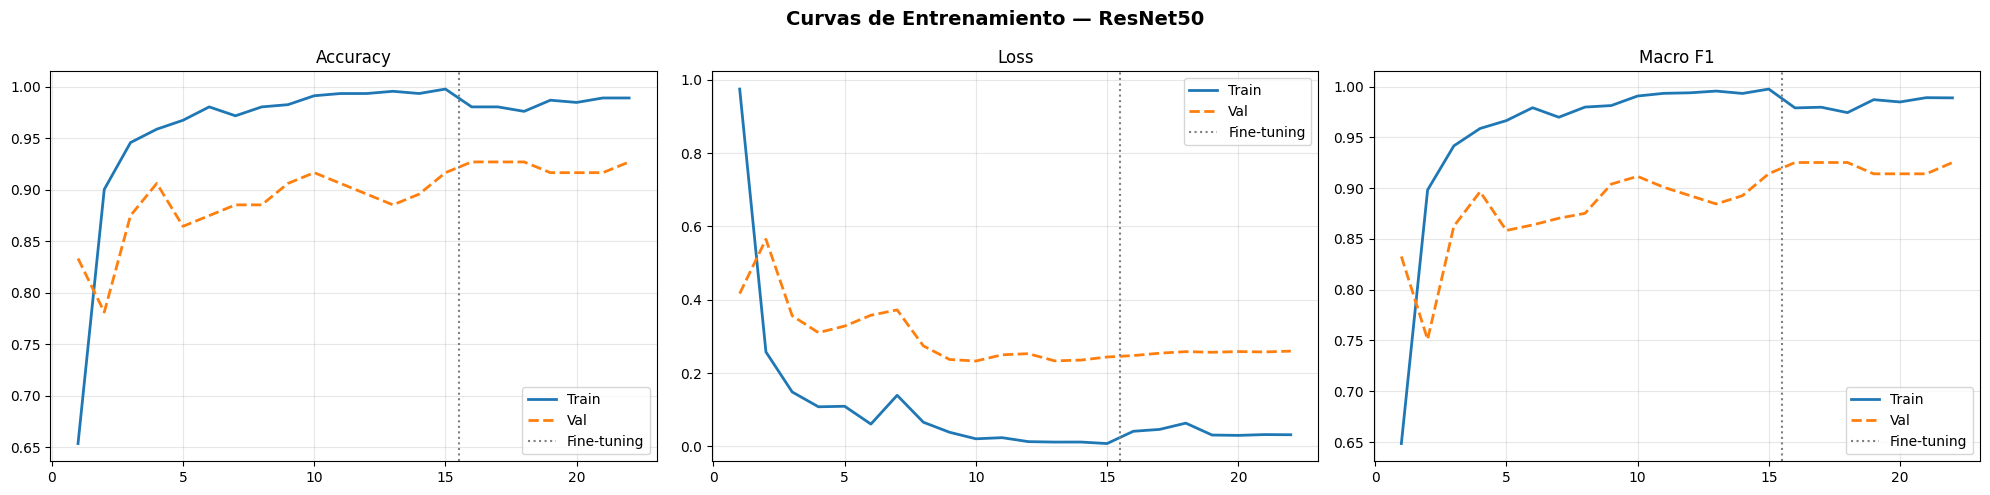

Guardado: training_curves.png


In [ ]:
# Combinar historial de ambas fases
acc      = history.history['accuracy']     + history_ft.history['accuracy']
val_acc  = history.history['val_accuracy'] + history_ft.history['val_accuracy']
loss     = history.history['loss']         + history_ft.history['loss']
val_loss = history.history['val_loss']     + history_ft.history['val_loss']
f1_tr    = history.history['macro_f1']     + history_ft.history['macro_f1']
f1_val   = history.history['val_macro_f1'] + history_ft.history['val_macro_f1']

total_epochs = len(acc)
epochs_range = range(1, total_epochs + 1)
ft_start     = len(history.history['accuracy']) + 0.5

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Curvas de Entrenamiento — ResNet50', fontsize=14, fontweight='bold')

for ax, tr, vl, title in zip(
    axes,
    [acc,  loss,  f1_tr],
    [val_acc, val_loss, f1_val],
    ['Accuracy', 'Loss', 'Macro F1']
):
    ax.plot(epochs_range, tr, label='Train', linewidth=2)
    ax.plot(epochs_range, vl, label='Val',   linewidth=2, linestyle='--')
    ax.axvline(x=ft_start, color='gray', linestyle=':', linewidth=1.5, label='Fine-tuning')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: training_curves.png')

## 9. Análisis

In [ ]:
# Prediciiones sobre el test
y_true, y_pred_probs = [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)


loss_val, acc_val, _ = model.evaluate(test_ds_fit, verbose=0)


macro_f1 = f1_score(y_true, y_pred, average='macro')

print('═' * 55)
print(f'  Test accuracy   : {acc_val:.4f}')
print(f'  Test loss       : {loss_val:.4f}')
print(f'  >>> MACRO F1    : {macro_f1:.4f}  <<<')
print('═' * 55)
print()
print('── Classification Report ──────────────────────────────────────────')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

═══════════════════════════════════════════════════════
  Test accuracy   : 0.9057
  Test loss       : 0.4258
  >>> MACRO F1    : 0.9062  <<<
═══════════════════════════════════════════════════════

── Classification Report ──────────────────────────────────────────
              precision    recall  f1-score   support

        cups     0.8077    0.9545    0.8750        22
       forks     0.9231    0.8571    0.8889        14
     glasses     0.8824    0.8333    0.8571        18
      knives     0.9286    0.8667    0.8966        15
      plates     0.9500    0.9500    0.9500        20
      spoons     1.0000    0.9412    0.9697        17

    accuracy                         0.9057       106
   macro avg     0.9153    0.9005    0.9062       106
weighted avg     0.9104    0.9057    0.9062       106



## 10. Matriz de confusión

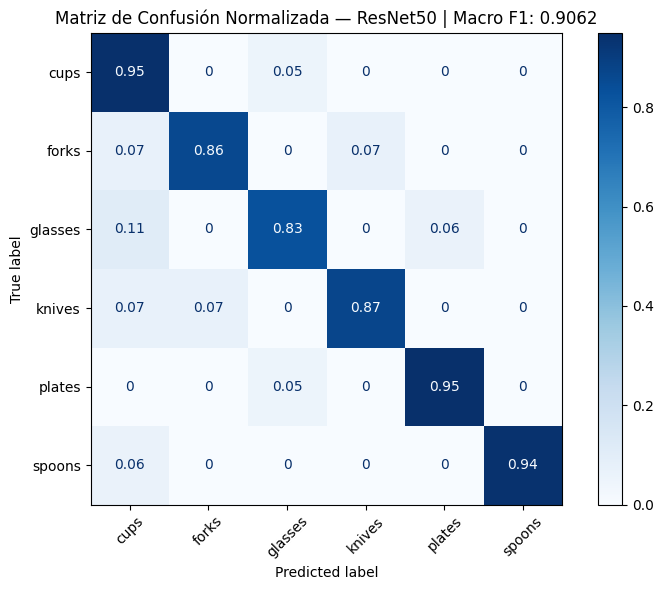

Guardado: confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 6))

ConfusionMatrixDisplay(
    np.round(cm_norm, 2),
    display_labels=class_names
).plot(
    ax=ax,
    colorbar=True,
    cmap='Blues',
    xticks_rotation=45
)

ax.set_title(f'Matriz de Confusión Normalizada — ResNet50 | Macro F1: {macro_f1:.4f}')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Guardado: confusion_matrix.png')

## 11. Imágenes mal clasificadas

Found 106 files belonging to 6 classes.
Imágenes mal clasificadas: 10 / 106  (error rate: 9.4%)


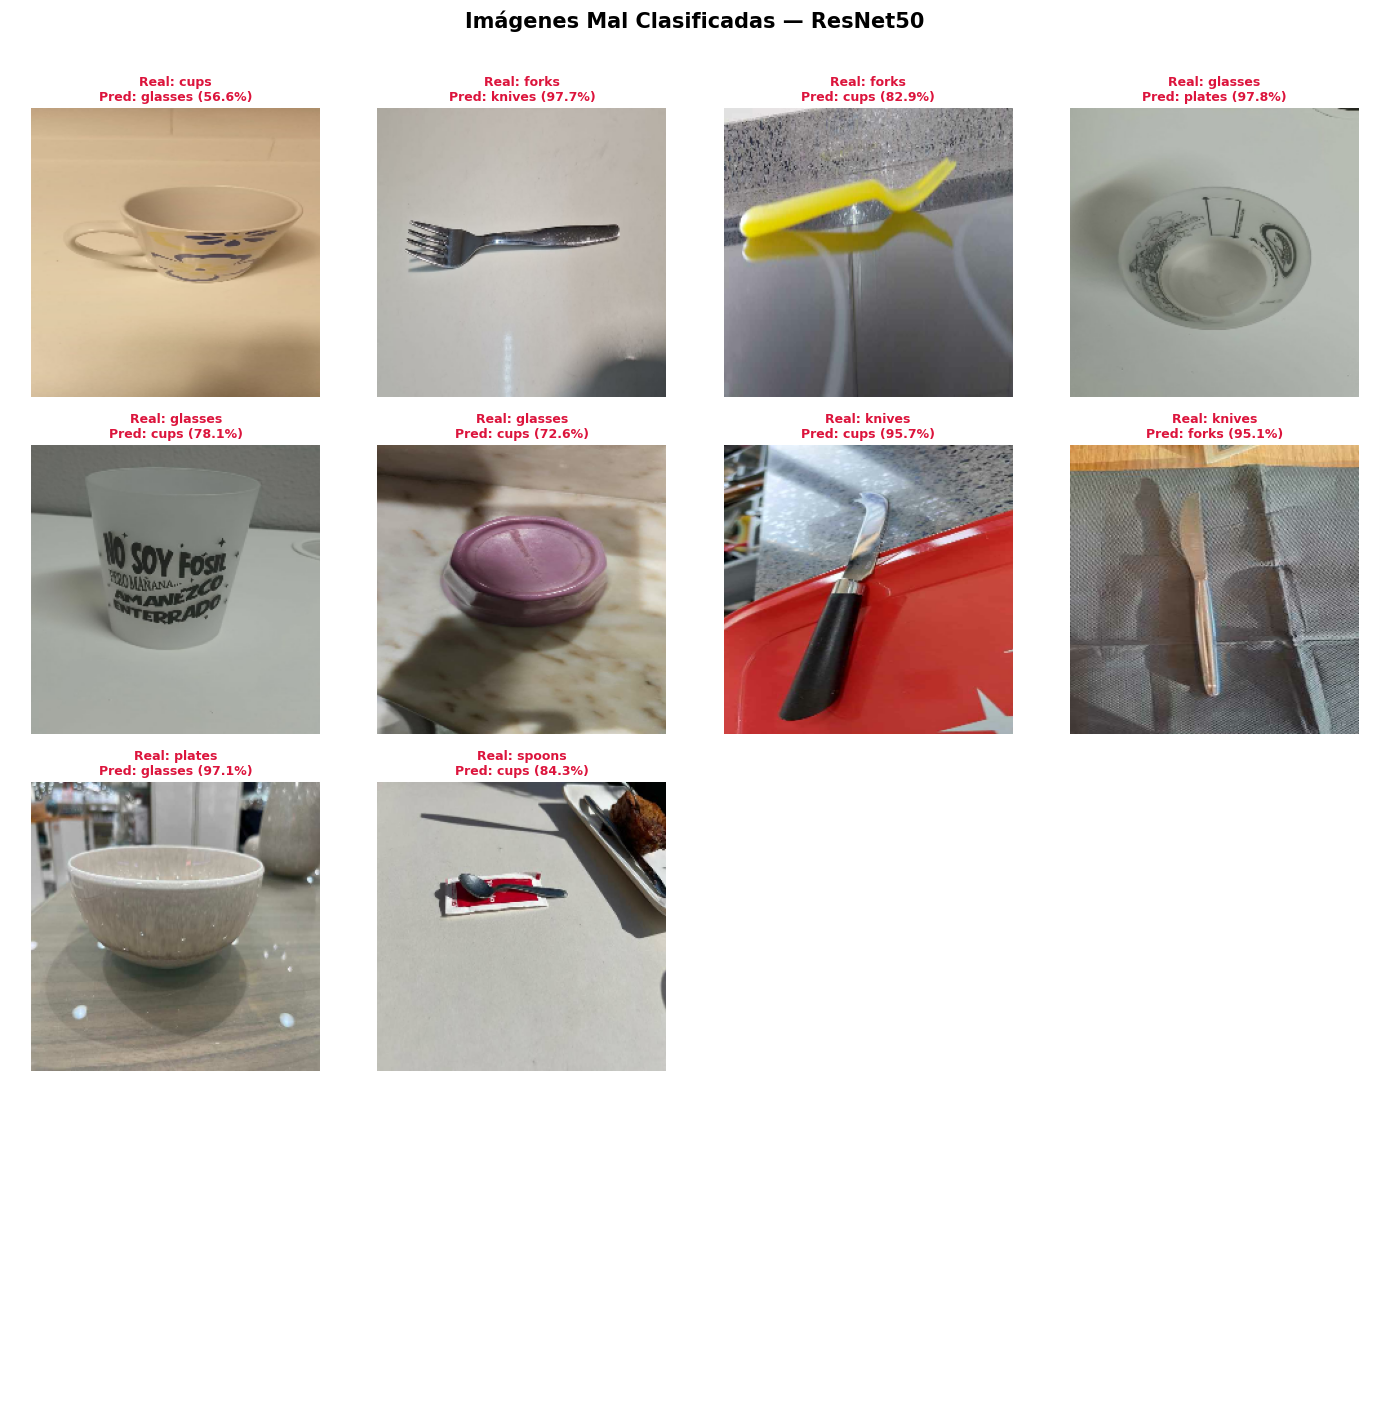

Guardado: misclassified_examples.png


In [ ]:

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    test_folder, seed=42,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

all_images = np.concatenate([imgs.numpy() for imgs, _ in test_ds_raw], axis=0).astype('uint8')

wrong_idx = np.where(y_pred != y_true)[0]
print(f'Imágenes mal clasificadas: {len(wrong_idx)} / {len(y_true)}  '
      f'(error rate: {len(wrong_idx)/len(y_true)*100:.1f}%)')

n_show = min(16, len(wrong_idx))

if n_show == 0:
    print('El modelo clasificó correctamente todas las imágenes del test')
else:
    fig, axes = plt.subplots(4, 4, figsize=(14, 14))
    fig.suptitle('Imágenes Mal Clasificadas — ResNet50', fontsize=15,
                 fontweight='bold', y=1.01)
    axes = axes.flatten()

    for i in range(16):
        ax = axes[i]
        if i < n_show:
            idx        = wrong_idx[i]
            true_label = class_names[y_true[idx]]
            pred_label = class_names[y_pred[idx]]
            confidence = y_pred_probs[idx][y_pred[idx]] * 100
            ax.imshow(all_images[idx])
            ax.set_title(
                f'Real: {true_label}\nPred: {pred_label} ({confidence:.1f}%)',
                fontsize=9, color='crimson', fontweight='bold'
            )
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('misclassified_examples.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Guardado: misclassified_examples.png')